In [1]:
!pip install numpy pandas pymysql python-dotenv matplotlib

In [2]:
import numpy as np
import pandas as pd
import pymysql
from pymysql.cursors import DictCursor
from datetime import datetime, timedelta
import random
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [3]:
load_dotenv("../.env")


DB_NAME = os.getenv('DB_NAME')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = int(os.getenv('DB_PORT'))

EPSILON = float(os.getenv('EPSILON'))

In [4]:
# Simulate demographic/behavioral data for households
np.random.seed(123)
num_households = 100

household_ids = np.arange(1, num_households + 1)
num_residents = np.random.choice([1, 2, 3, 4, 5], size=num_households, p=[0.15, 0.3, 0.25, 0.2, 0.1])
house_type = np.random.choice(['apartment', 'villa'], size=num_households, p=[0.7, 0.3])
income_level = np.random.choice(['low', 'medium', 'high'], size=num_households, p=[0.2, 0.5, 0.3])
activity_pattern = np.random.choice([0, 1, 2], size=num_households, p=[0.6, 0.2, 0.2])

household_df = pd.DataFrame({
    'household_id': household_ids,
    'num_residents': num_residents,
    'house_type': house_type,
    'income_level': income_level,
    'activity_pattern': activity_pattern
})

noisy_residents = np.round(household_df['num_residents'] + np.random.laplace(0, 1.0/EPSILON, len(household_df)))
noisy_residents = noisy_residents.clip(lower=1)
household_df['num_residents_dp'] = noisy_residents.astype(int)

household_df['num_residents_original'] = household_df['num_residents']
household_df = household_df.drop(columns=['num_residents'])

print(household_df)

    household_id house_type income_level  activity_pattern  num_residents_dp  \
0              1  apartment       medium                 0                 3   
1              2  apartment          low                 1                 1   
2              3  apartment       medium                 0                 6   
3              4  apartment         high                 0                 2   
4              5  apartment         high                 0                 7   
..           ...        ...          ...               ...               ...   
95            96  apartment         high                 0                 9   
96            97  apartment         high                 0                 5   
97            98      villa         high                 0                 6   
98            99  apartment          low                 0                 2   
99           100  apartment       medium                 2                 3   

    num_residents_original  
0         

In [5]:
# Simulation parameters
START_DATE = datetime(2023, 1, 1, 0, 0, 0)
NUM_HOURS = 24 * 365
BASE_CONSUMPTION = 0.8 
SEASONAL_AMPLITUDE = 0.4
DAILY_AMPLITUDE = 0.3
RANDOM_NOISE_SCALE = 0.1

In [6]:
dates = [START_DATE + timedelta(hours=i) for i in range(NUM_HOURS)]
base_df = pd.DataFrame({'timestamp': dates})
base_df['hour'] = base_df['timestamp'].dt.hour
base_df['day_of_year'] = base_df['timestamp'].dt.dayofyear
base_df['month'] = base_df['timestamp'].dt.month
base_df['day_of_week'] = base_df['timestamp'].dt.dayofweek

# Seasonal factor
seasonal_factor = 0.5 + 0.5 * np.sin(2 * np.pi * (base_df['day_of_year'] - 80) / 365.0)
seasonal_factor = 0.6 + 0.8 * seasonal_factor

# Daily pattern
def daily_pattern(hour):
    if 0 <= hour < 6:
        return 0.6
    elif 6 <= hour < 10:
        return 0.9
    elif 10 <= hour < 16:
        return 0.8
    elif 16 <= hour < 18:
        return 0.9
    elif 18 <= hour < 22:
        return 1.4
    else:
        return 1.0

base_df['daily_factor'] = base_df['hour'].apply(daily_pattern)
base_df['weekend_factor'] = 1.0
base_df.loc[base_df['day_of_week'] >= 5, 'weekend_factor'] = 1.15

# Simulate weather data (shared across all households, city-level)
def temperature(day):
    return 20 + 15 * np.sin(2 * np.pi * (day - 80) / 365.0) + np.random.normal(0, 2)

def humidity(day, temp):
    base = 70 - 0.5 * (temp - 20)
    return np.clip(base + np.random.normal(0, 10), 20, 100)

In [7]:
np.random.seed(42)
base_df['temperature_c'] = base_df['day_of_year'].apply(temperature)
base_df['humidity_percent'] = base_df.apply(lambda row: humidity(row['day_of_year'], row['temperature_c']), axis=1)

# House type factor for per-household consumption scaling
house_type_factor_map = {'apartment': 0.85, 'villa': 1.25}

# Generate consumption per household
np.random.seed(42)
all_household_energy = []

for _, hh in household_df.iterrows():
    hh_id = hh['household_id']
    residents_factor = 1 + 0.15 * (hh['num_residents_dp'] - 1)
    type_factor = house_type_factor_map.get(hh['house_type'], 1.0)
    activity_factor = 1 + 0.1 * hh['activity_pattern']

    base_consumption = (BASE_CONSUMPTION * residents_factor * type_factor * activity_factor *
                         seasonal_factor * base_df['daily_factor'] * base_df['weekend_factor'])

    random_noise = np.random.normal(0, RANDOM_NOISE_SCALE, NUM_HOURS)
    consumption_kwh = (base_consumption + random_noise).clip(lower=0.0)

    temp_df = pd.DataFrame({
        'household_id': hh_id,
        'timestamp': base_df['timestamp'],
        'consumption_kwh': consumption_kwh,
        'temperature_c': base_df['temperature_c'],
        'humidity_percent': base_df['humidity_percent']
    })
    all_household_energy.append(temp_df)

df_final = pd.concat(all_household_energy, ignore_index=True)

print(df_final.shape)
df_final.head()

(876000, 5)


,household_id,timestamp,consumption_kwh,temperature_c,humidity_percent
0,1,2023-01-01 00:00:00,0.421052,6.325703,86.551272
1,1,2023-01-01 01:00:00,0.357554,5.055746,64.519541
2,1,2023-01-01 02:00:00,0.436150,6.627652,64.810642
3,1,2023-01-01 03:00:00,0.523684,8.378335,81.599931
4,1,2023-01-01 04:00:00,0.347965,4.863968,76.924639


In [8]:
conn = pymysql.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME,
    port=DB_PORT,
    charset='utf8mb4'
)
cursor = conn.cursor()

schema_file = '../data/schema.sql'

with open(schema_file, 'r') as f:
    schema_sql = f.read()
    # Split into statements (simple split by ';')
    for statement in schema_sql.split(';'):
        if statement.strip():
            cursor.execute(statement)
conn.commit()

In [9]:
for _, row in household_df.iterrows():
    cursor.execute(
        "INSERT INTO households (household_id, num_residents, house_type, income_level, activity_pattern, num_residents_original) "
        "VALUES (%s, %s, %s, %s, %s, %s)",
        (row['household_id'], row['num_residents_dp'], row['house_type'], row['income_level'],
         row['activity_pattern'], row['num_residents_original'])
    )
conn.commit()

In [10]:
df_final['timestamp'] = df_final['timestamp'].astype(str)

data_to_insert = list(df_final[['household_id', 'timestamp', 'consumption_kwh', 
                                  'temperature_c', 'humidity_percent']].itertuples(index=False, name=None))

insert_query = """
    INSERT INTO energy_consumption (household_id, timestamp, consumption_kwh, temperature_c, humidity_percent)
    VALUES (%s, %s, %s, %s, %s)
"""

cursor.executemany(insert_query, data_to_insert)
conn.commit()

In [11]:
cursor.execute("SELECT COUNT(*) FROM energy_consumption")
print("energy_consumption rows:", cursor.fetchone()[0])
cursor.execute("SELECT COUNT(*) FROM households")
print("households rows:", cursor.fetchone()[0])

energy_consumption rows: 876000
households rows: 100


In [12]:
def run_query(conn, query, params=None):
    """Execute SQL query and return results as pandas DataFrame."""
    return pd.read_sql(query, conn, params=params)
    
def monthly_avg_consumption(conn):
    query = """
        SELECT DATE_FORMAT(timestamp, '%Y-%m') AS month,
               ROUND(AVG(consumption_kwh), 2) AS avg_consumption
        FROM energy_consumption
        GROUP BY month
        ORDER BY month;
    """
    return pd.read_sql(query, conn)

def weekday_vs_weekend(conn):
    query = """
        SELECT CASE WHEN DAYOFWEEK(timestamp) IN (1,7) THEN 'Weekend' ELSE 'Weekday' END AS day_type,
               ROUND(AVG(consumption_kwh), 2) AS avg_consumption
        FROM energy_consumption
        GROUP BY day_type;
    """
    return pd.read_sql(query, conn)

def correlation_temp_consumption(conn):
    query = """
        SELECT 
            (SUM((consumption_kwh - avg_c) * (temperature_c - avg_t)) /
            (COUNT(*) * STDDEV(consumption_kwh) * STDDEV(temperature_c))) AS correlation
        FROM energy_consumption,
             (SELECT AVG(consumption_kwh) AS avg_c, AVG(temperature_c) AS avg_t FROM energy_consumption) AS stats;
    """
    return pd.read_sql(query, conn)

def top_peak_hours(conn):
    query = """
        SELECT HOUR(timestamp) AS hour,
               ROUND(AVG(consumption_kwh), 2) AS avg_consumption
        FROM energy_consumption
        GROUP BY hour
        ORDER BY avg_consumption DESC
        LIMIT 5;
    """
    return pd.read_sql(query, conn)

def consumption_by_house_type(conn):
    query = """
        SELECT h.house_type,
               ROUND(AVG(e.consumption_kwh), 2) AS avg_consumption
        FROM energy_consumption e
        JOIN households h ON e.household_id = h.household_id
        GROUP BY h.house_type;
    """
    return pd.read_sql(query, conn)

def consumption_by_income(conn):
    query = """
        SELECT h.income_level,
               ROUND(AVG(e.consumption_kwh), 2) AS avg_consumption
        FROM energy_consumption e
        JOIN households h ON e.household_id = h.household_id
        GROUP BY h.income_level
        ORDER BY avg_consumption DESC;
    """
    return pd.read_sql(query, conn)

def consumption_by_activity_pattern(conn):
    query = """
        SELECT h.activity_pattern,
               CASE h.activity_pattern
                   WHEN 0 THEN 'Day shift'
                   WHEN 1 THEN 'Night shift'
                   WHEN 2 THEN 'Mixed'
               END AS pattern_label,
               ROUND(AVG(e.consumption_kwh), 2) AS avg_consumption
        FROM energy_consumption e
        JOIN households h ON e.household_id = h.household_id
        GROUP BY h.activity_pattern
        ORDER BY avg_consumption DESC;
    """
    return pd.read_sql(query, conn)

def seasonal_profile(conn):
    query = """
        SELECT MONTH(timestamp) AS month,
               ROUND(AVG(consumption_kwh), 2) AS avg_consumption,
               ROUND(AVG(temperature_c), 2) AS avg_temp
        FROM energy_consumption
        GROUP BY month
        ORDER BY month;
    """
    return pd.read_sql(query, conn)

def daily_profile(conn):
    query = """
        SELECT HOUR(timestamp) AS hour,
               ROUND(AVG(consumption_kwh), 2) AS avg_consumption
        FROM energy_consumption
        GROUP BY hour
        ORDER BY hour;
    """
    return pd.read_sql(query, conn)

def correlation_humidity_consumption(conn):
    query = """
        SELECT 
            (SUM((consumption_kwh - avg_c) * (humidity_percent - avg_h)) /
            (COUNT(*) * STDDEV(consumption_kwh) * STDDEV(humidity_percent))) AS correlation
        FROM energy_consumption,
             (SELECT AVG(consumption_kwh) AS avg_c, AVG(humidity_percent) AS avg_h FROM energy_consumption) AS stats;
    """
    return pd.read_sql(query, conn)

def top_consuming_households(conn, limit=10):
    query = """
        SELECT household_id,
               ROUND(AVG(consumption_kwh), 2) AS avg_consumption,
               COUNT(*) AS records
        FROM energy_consumption
        GROUP BY household_id
        ORDER BY avg_consumption DESC
        LIMIT %s;
    """
    return pd.read_sql(query, conn, params=(limit,))

def consumption_outliers(conn, threshold=2):
    query = """
        SELECT household_id,
               ROUND(AVG(consumption_kwh), 2) AS avg_cons,
               ROUND(STDDEV(consumption_kwh), 2) AS std_cons,
               ROUND(AVG(consumption_kwh) + STDDEV(consumption_kwh) * %s, 2) AS upper_bound
        FROM energy_consumption
        GROUP BY household_id
        HAVING STDDEV(consumption_kwh) > (SELECT AVG(std) FROM (SELECT STDDEV(consumption_kwh) AS std FROM energy_consumption GROUP BY household_id) AS t)
        ORDER BY std_cons DESC
        LIMIT 10;
    """
    return pd.read_sql(query, conn, params=(threshold,))

analysis_functions = [
    ("Monthly average consumption", monthly_avg_consumption),
    ("Weekday vs Weekend", weekday_vs_weekend),
    ("Correlation (temperature vs consumption)", correlation_temp_consumption),
    ("Top 5 peak hours", top_peak_hours),
    ("Consumption by house type", consumption_by_house_type),
    ("Consumption by income level", consumption_by_income),
    ("Consumption by activity pattern", consumption_by_activity_pattern),
    ("Seasonal profile (monthly)", seasonal_profile),
    ("Daily profile (hourly)", daily_profile),
    ("Correlation (humidity vs consumption)", correlation_humidity_consumption),
    ("Top 10 consuming households", top_consuming_households),
    ("Consumption outliers (high variance)", consumption_outliers),
]

for name, func in analysis_functions:
    print(f"\n{'='*60}")
    print(f"** {name} **")
    print('='*60)
    df = func(conn)
    if df.empty:
        print("No data returned.")
    else:
        print(df.to_string(index=False))
    print("\n")


** Monthly average consumption **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


  month  avg_consumption
2023-01             0.68
2023-02             0.81
2023-03             1.00
2023-04             1.23
2023-05             1.38
2023-06             1.45
2023-07             1.42
2023-08             1.27
2023-09             1.07
2023-10             0.86
2023-11             0.70
2023-12             0.64



** Weekday vs Weekend **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


day_type  avg_consumption
 Weekday             1.00
 Weekend             1.15



** Correlation (temperature vs consumption) **


...

 correlation
   -0.218963



** Top 10 consuming households **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:123: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn, params=(limit,))


 household_id  avg_consumption  records
           75             2.87     8760
           92             2.46     8760
           52             1.95     8760
           26             1.91     8760
           23             1.67     8760
           98             1.63     8760
           46             1.63     8760
           47             1.63     8760
            7             1.63     8760
           20             1.63     8760



** Consumption outliers (high variance) **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:137: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn, params=(threshold,))


 household_id  avg_cons  std_cons  upper_bound
           75      2.87      1.21         5.28
           92      2.46      1.04         4.54
           52      1.95      0.83         3.60
           26      1.91      0.81         3.52
           23      1.67      0.71         3.09
            7      1.63      0.69         3.01
           98      1.63      0.69         3.01
           46      1.63      0.69         3.01
           20      1.63      0.69         3.01
           47      1.63      0.69         3.01




In [14]:
os.makedirs('../data/generated-dataset', exist_ok=True)

household_df.to_excel('../data/generated-dataset/households.xlsx', index=False)
df_final.to_excel('../data/generated-dataset/energy_consumption.xlsx', index=False)

print("Excel files saved: households.xlsx, energy_consumption.xlsx")

Excel files saved: households.xlsx, energy_consumption.xlsx



** Monthly average consumption **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


  month  avg_consumption
2023-01             0.68
2023-02             0.81
2023-03             1.00
2023-04             1.23
2023-05             1.38
2023-06             1.45
2023-07             1.42
2023-08             1.27
2023-09             1.07
2023-10             0.86
2023-11             0.70
2023-12             0.64


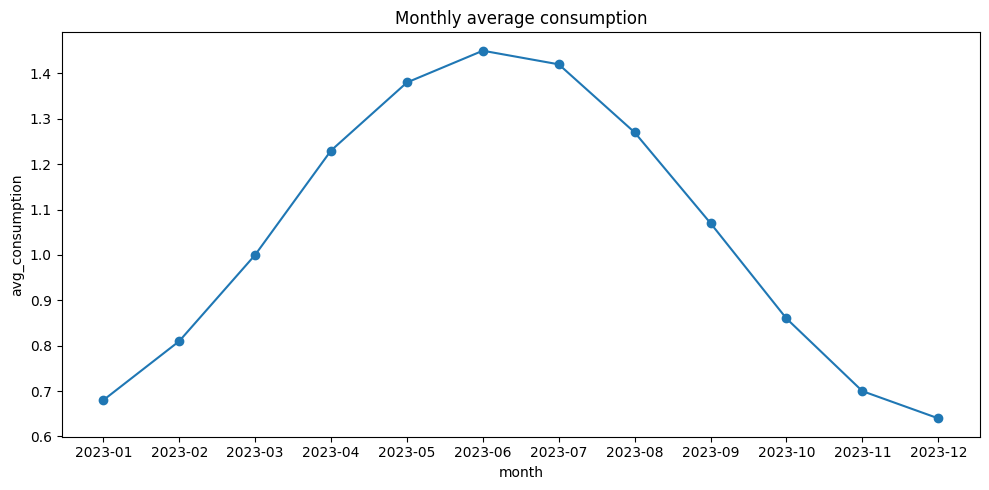




** Weekday vs Weekend **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


day_type  avg_consumption
 Weekday             1.00
 Weekend             1.15


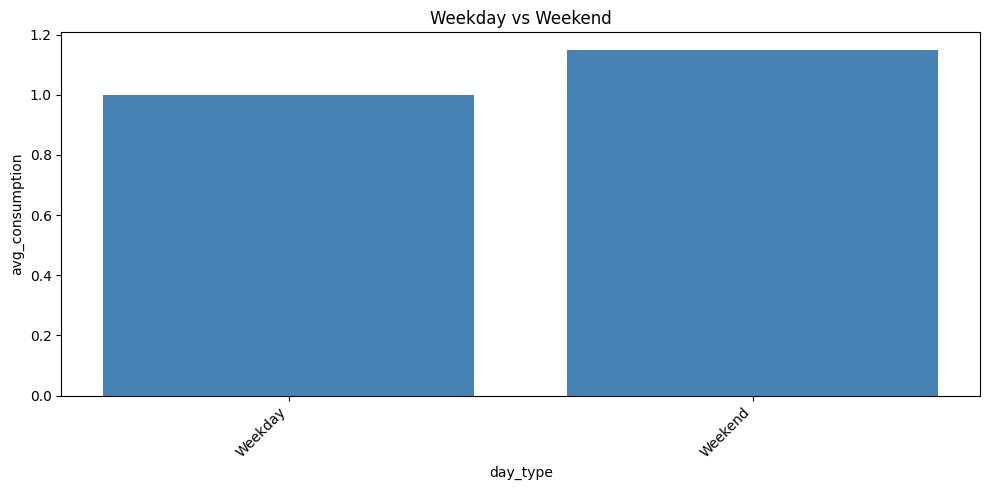




** Correlation (temperature vs consumption) **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


 correlation
    0.472526


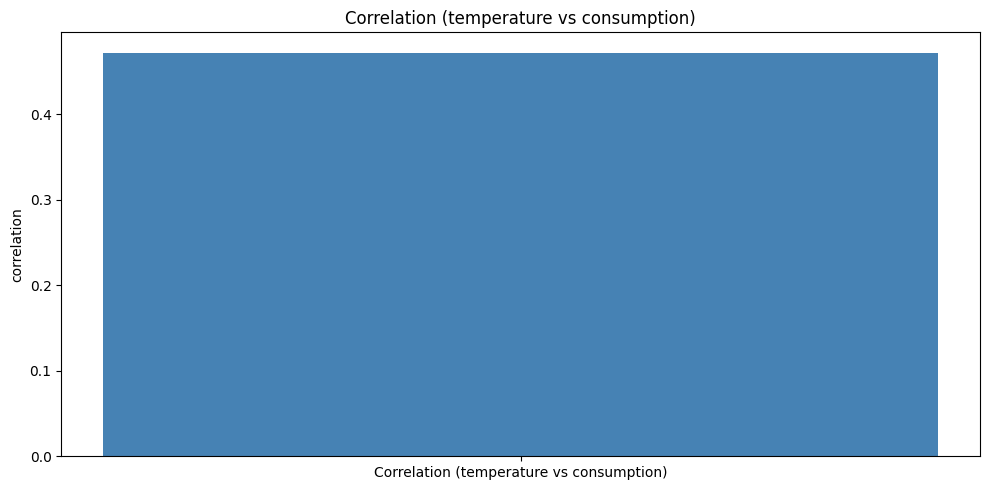




** Top 5 peak hours **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:43: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


 hour  avg_consumption
   21             1.64
   18             1.64
   19             1.64
   20             1.64
   22             1.17


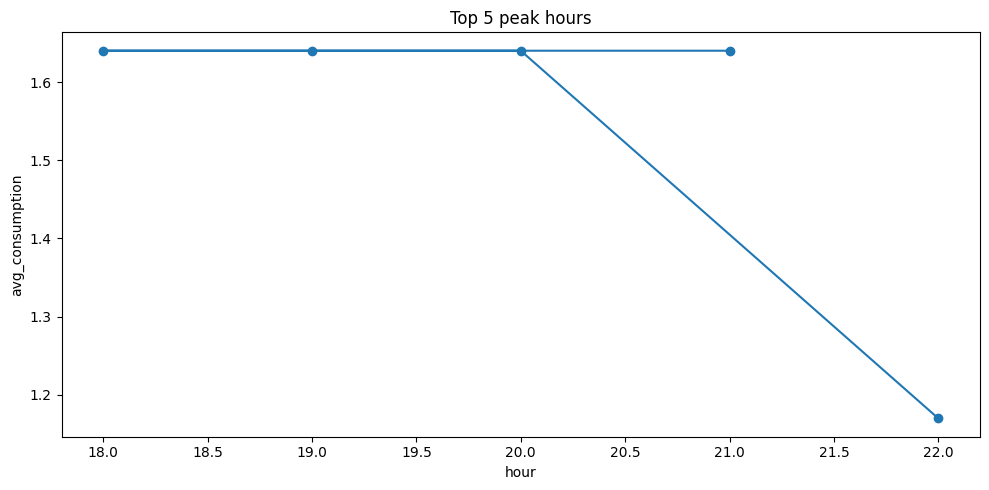




** Consumption by house type **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


house_type  avg_consumption
 apartment             0.89
     villa             1.39


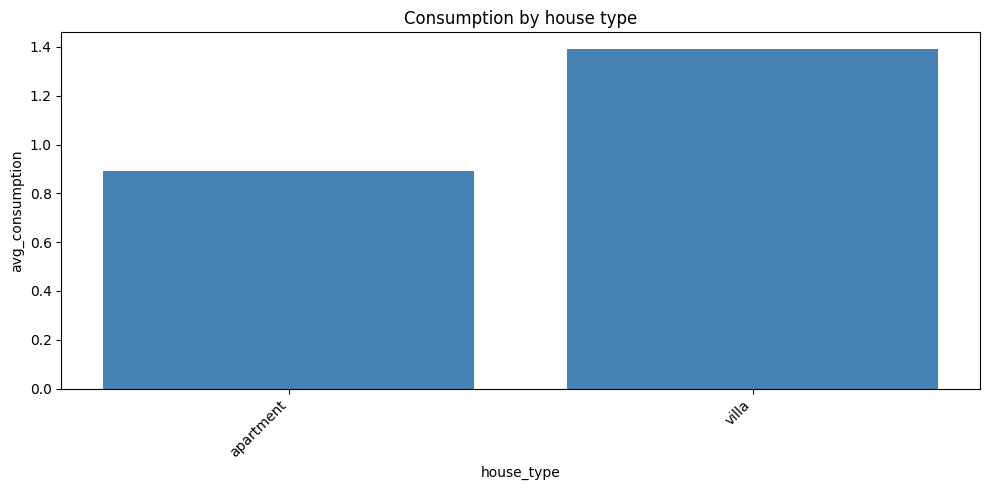




** Consumption by income level **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:64: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


income_level  avg_consumption
        high             1.08
      medium             1.06
         low             0.96


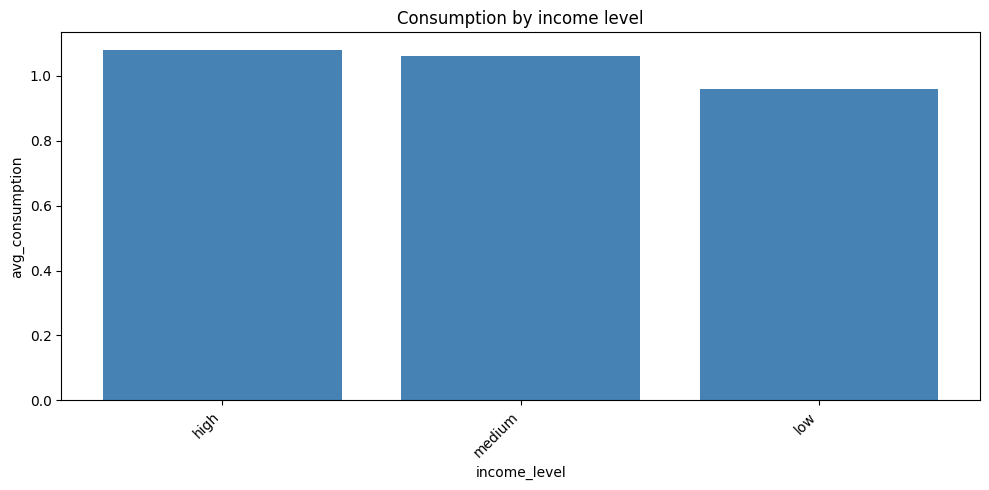




** Consumption by activity pattern **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:80: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


 activity_pattern pattern_label  avg_consumption
                2         Mixed             1.10
                1   Night shift             1.06
                0     Day shift             1.02


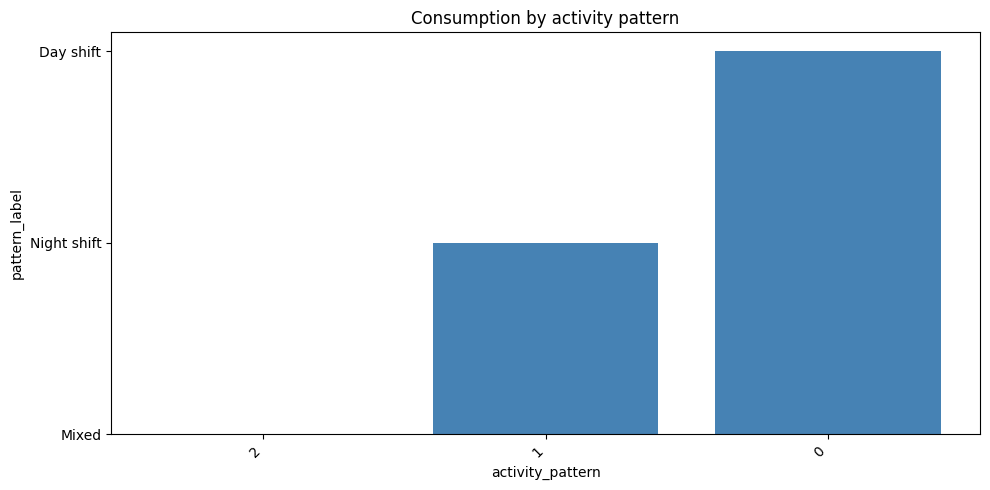




** Seasonal profile (monthly) **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:91: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


 month  avg_consumption  avg_temp
     1             0.68      6.75
     2             0.81     11.88
     3             1.00     18.79
     4             1.23     26.36
     5             1.38     32.17
     6             1.45     34.64
     7             1.42     33.37
     8             1.27     28.20
     9             1.07     20.93
    10             0.86     13.44
    11             0.70      7.72
    12             0.64      5.26


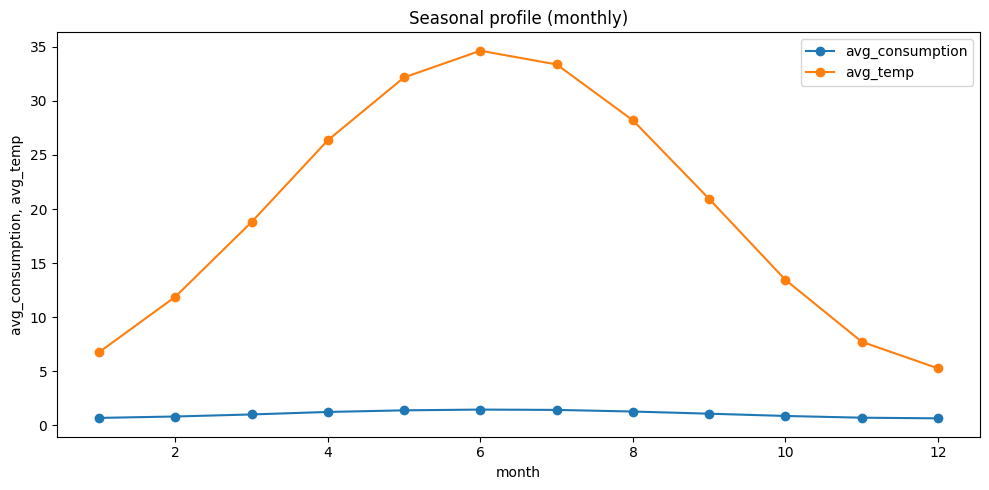




** Daily profile (hourly) **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:101: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


 hour  avg_consumption
    0             0.70
    1             0.70
    2             0.70
    3             0.70
    4             0.70
    5             0.70
    6             1.05
    7             1.05
    8             1.05
    9             1.05
   10             0.94
   11             0.94
   12             0.94
   13             0.94
   14             0.94
   15             0.94
   16             1.05
   17             1.05
   18             1.64
   19             1.64
   20             1.64
   21             1.64
   22             1.17
   23             1.17


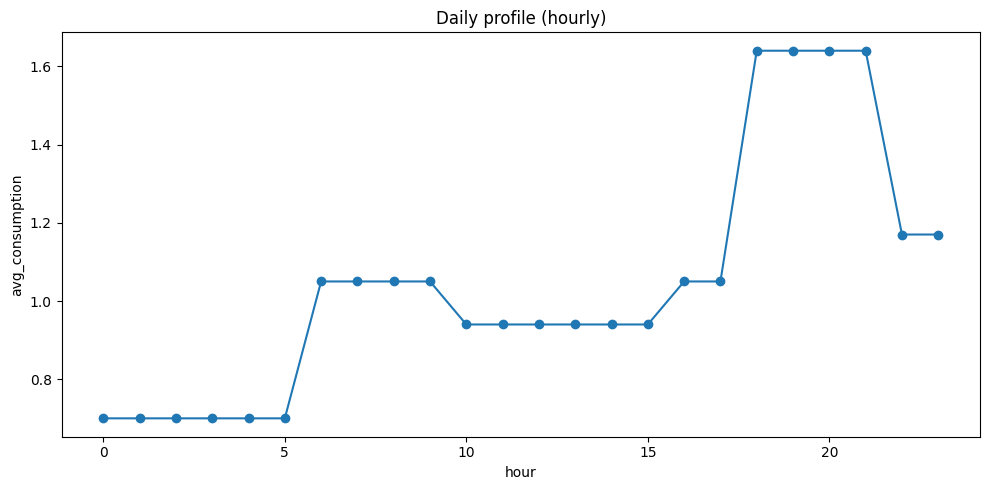




** Correlation (humidity vs consumption) **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:111: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


 correlation
   -0.218963


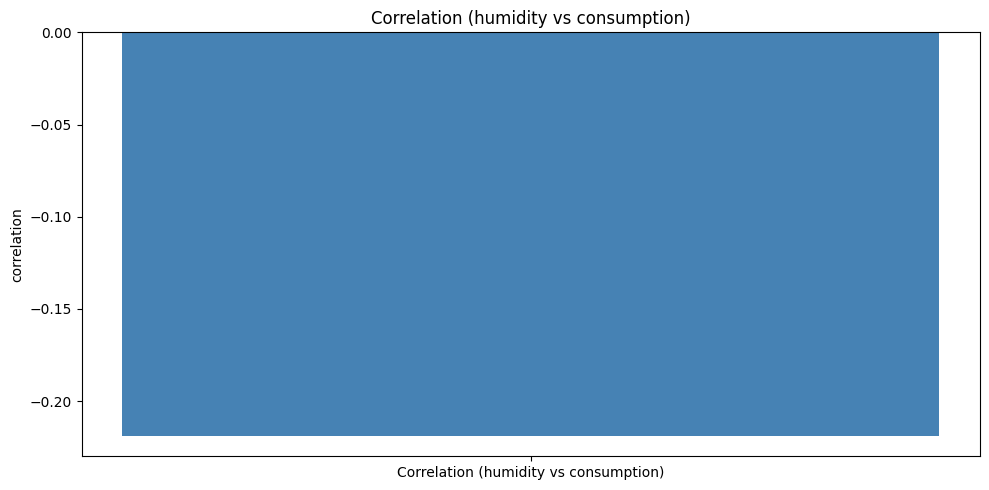




** Top 10 consuming households **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:123: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn, params=(limit,))


 household_id  avg_consumption  records
           75             2.87     8760
           92             2.46     8760
           52             1.95     8760
           26             1.91     8760
           23             1.67     8760
           98             1.63     8760
           46             1.63     8760
           47             1.63     8760
            7             1.63     8760
           20             1.63     8760


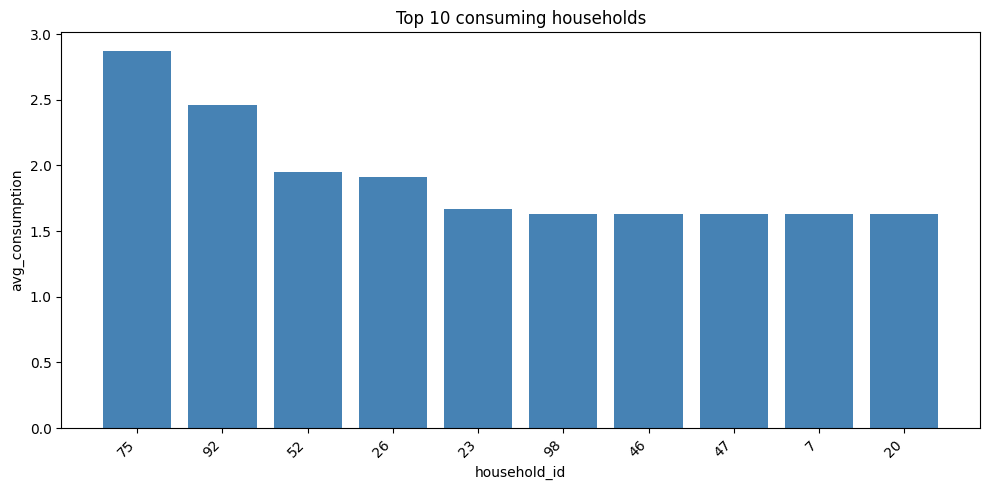




** Consumption outliers (high variance) **


C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_1732\944234471.py:137: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn, params=(threshold,))


 household_id  avg_cons  std_cons  upper_bound
           75      2.87      1.21         5.28
           92      2.46      1.04         4.54
           52      1.95      0.83         3.60
           26      1.91      0.81         3.52
           23      1.67      0.71         3.09
            7      1.63      0.69         3.01
           98      1.63      0.69         3.01
           46      1.63      0.69         3.01
           20      1.63      0.69         3.01
           47      1.63      0.69         3.01


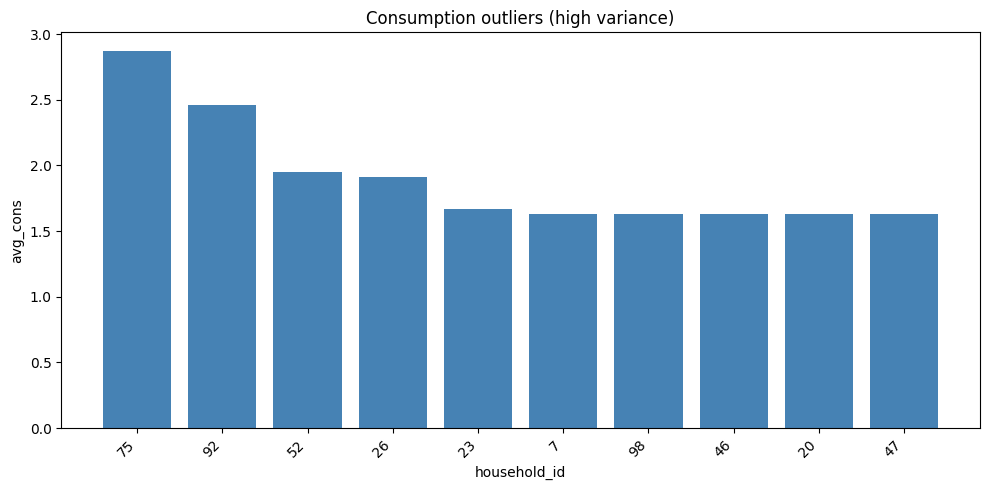

In [17]:
os.makedirs('results', exist_ok=True)

def plot_and_save(df, name, filename):
    plt.figure(figsize=(10, 5))

    cols = df.columns.tolist()

    # single scalar value (correlation queries)
    if df.shape[0] == 1 and df.shape[1] == 1:
        value = df.iloc[0, 0]
        plt.bar([name], [value], color='steelblue')
        plt.ylabel(cols[0])
        plt.title(name)

    # time-based (hour / month) -> line plot
    elif cols[0] in ('hour', 'month'):
        x = df[cols[0]]
        for col in cols[1:]:
            plt.plot(x, df[col], marker='o', label=col)
        plt.xlabel(cols[0])
        plt.ylabel(', '.join(cols[1:]))
        plt.title(name)
        if len(cols) > 2:
            plt.legend()

    # categorical -> bar plot
    else:
        x = df[cols[0]].astype(str)
        y_col = cols[1]
        plt.bar(x, df[y_col], color='steelblue')
        plt.xlabel(cols[0])
        plt.ylabel(y_col)
        plt.title(name)
        plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f'results/{filename}.png', dpi=150)
    plt.show()
    plt.close()


for name, func in analysis_functions:
    print(f"\n{'='*60}")
    print(f"** {name} **")
    print('='*60)
    df = func(conn)
    if df.empty:
        print("No data returned.")
    else:
        print(df.to_string(index=False))
        filename = func.__name__
        plot_and_save(df, name, filename)
    print("\n")
